In [2]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
pd.set_option('display.max_columns', None)

# Consistent style for all charts
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = sns.color_palette('muted')

In [3]:
# Load the data frames required for analysis
# Files from my PC folder
df1 = pd.read_csv(r"/home/isaac-matere/Data Analysis/Python/Retail Store Sales/stores.csv")
df2 = pd.read_csv(r"/home/isaac-matere/Data Analysis/Python/Retail Store Sales/sales.csv")
df3 = pd.read_csv(r"/home/isaac-matere/Data Analysis/Python/Retail Store Sales/features.csv")

In [4]:
print(df1.shape, df2.shape, df3.shape)

(50, 4) (156000, 5) (7800, 14)


In [5]:
# Merge the data frames. 
df = df2.merge(df1, on='store_id', how='left').merge(df3, on=['store_id', 'date'], how='left')

In [6]:
df.head(5)

,store_id,department,date,weekly_sales,is_holiday_x,store_type,store_size,region,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday_y,holiday_name,season
0,1,1,2022-01-01,119075.96,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2,2022-01-01,119107.85,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
2,1,3,2022-01-01,84369.88,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
3,1,4,2022-01-01,88445.24,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
4,1,5,2022-01-01,65159.85,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter


In [7]:
# Changing the columns for the titles to start with capital letters
df = df.rename(columns={
    'store_id' : 'Store_Id', 'department' : 'Department',
    'date' : 'Date', 'weekly_sales' : 'Weekly_Sales',
    'is_holiday_x' : 'Is_Holiday', 'store_type' : 'Store_Type',
    'store_size' : 'Store_Size', 'region' : 'Region',
    'temperature' : 'Temperature', 'fuel_price' : 'Fuel_Price',
    'markdown_1' : 'Markdown_1', 'markdown_2' : 'Markdown_2',
    'markdown_3' : 'Markdown_3', 'markdown_4' : 'Markdown_4',
    'markdown_5' : 'Markdown_5', 'cpi' : 'CPI',
    'unemployment' : 'Unemployment', 'is_holiday_y' : 'Is_Holiday_Features',
    'holiday_name' : 'Holiday_Name', 'season' : 'Season'
})

In [8]:
df = df.rename(columns={'Is_Holiday_Sales' : 'Is_Holiday'})
df = df.drop(columns='Is_Holiday_Features')

In [9]:
# An overview of the data types
df.dtypes

Store_Id          int64
Department        int64
Date                str
Weekly_Sales    float64
Is_Holiday        int64
Store_Type          str
Store_Size        int64
Region              str
Temperature     float64
Fuel_Price      float64
Markdown_1      float64
Markdown_2      float64
Markdown_3      float64
Markdown_4      float64
Markdown_5      float64
CPI             float64
Unemployment    float64
Holiday_Name        str
Season              str
dtype: object

In [22]:
# Dates dtypes are set as strings, convert to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Store_Id                 int64
Department               int64
Date            datetime64[us]
Weekly_Sales           float64
Is_Holiday               int64
Store_Type                 str
Store_Size               int64
Region                     str
Temperature            float64
Fuel_Price             float64
Markdown_1             float64
Markdown_2             float64
Markdown_3             float64
Markdown_4             float64
Markdown_5             float64
CPI                    float64
Unemployment           float64
Holiday_Name               str
Season                     str
dtype: object

In [11]:
# Shape of the data frame
print('Shape:', df.shape)

Shape: (156000, 19)


---
## Dataset Overview

Understanding what the data contains, row counts, missing values and some basic statistics

In [12]:
# Date range covered by the dataset
# Total weeks in the dataset
# Number of stores and Departments
# Number of rows
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total weeks: {df['Date'].nunique()}")
print(f"Stores: {df['Store_Id'].nunique()}")
print(f"Departments: {df['Department'].nunique()}")
print(f"Total rows: {len(df):,}")

Date range: 2022-01-01 to 2024-12-21
Total weeks: 156
Stores: 50
Departments: 20
Total rows: 156,000


In [13]:
# Summary stats for numeric columns
df.describe().round(2)

,Store_Id,Department,Date,Weekly_Sales,Is_Holiday,Store_Size,Temperature,Fuel_Price,Markdown_1,Markdown_2,Markdown_3,Markdown_4,Markdown_5,CPI,Unemployment
count,156000.00,156000.00,156000,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00,156000.00
mean,25.50,10.50,2023-06-27 12:00:00,56503.49,0.12,136626.44,59.88,3.99,2831.84,1708.09,2295.92,1982.04,2561.79,240.47,6.49
min,1.00,1.00,2022-01-01 00:00:00,819.66,0.00,31639.00,20.02,2.50,0.18,0.20,1.01,1.13,0.14,180.00,3.00
25%,13.00,5.75,2022-09-29 06:00:00,21255.96,0.00,91417.00,39.94,3.24,1308.73,787.16,1095.92,969.92,1198.38,211.03,4.72
50%,25.50,10.50,2023-06-27 12:00:00,43394.87,0.00,140736.50,60.06,3.97,2652.50,1612.57,2174.60,1862.98,2417.90,240.94,6.49
75%,38.00,15.25,2024-03-24 18:00:00,79604.11,0.00,179797.00,79.91,4.75,4027.54,2423.00,3212.70,2790.14,3600.24,270.44,8.22
max,50.00,20.00,2024-12-21 00:00:00,505958.73,1.00,218696.00,99.97,5.50,10977.07,6599.72,8798.15,7692.88,9891.19,299.99,10.00
std,14.43,5.77,NaN,46717.49,0.32,53081.47,23.11,0.86,1977.83,1187.62,1579.28,1351.45,1769.69,34.60,2.01


In [14]:
# Finding out the missing values
# Holiday Name is null for non holidays, null values will be expected
missing = df.isnull().sum()
print(missing[missing > 0])

Holiday_Name    138000
dtype: int64


---
## Weekly Sales Distribution

This is to understand how the Weekly sales are distributed across the dataset

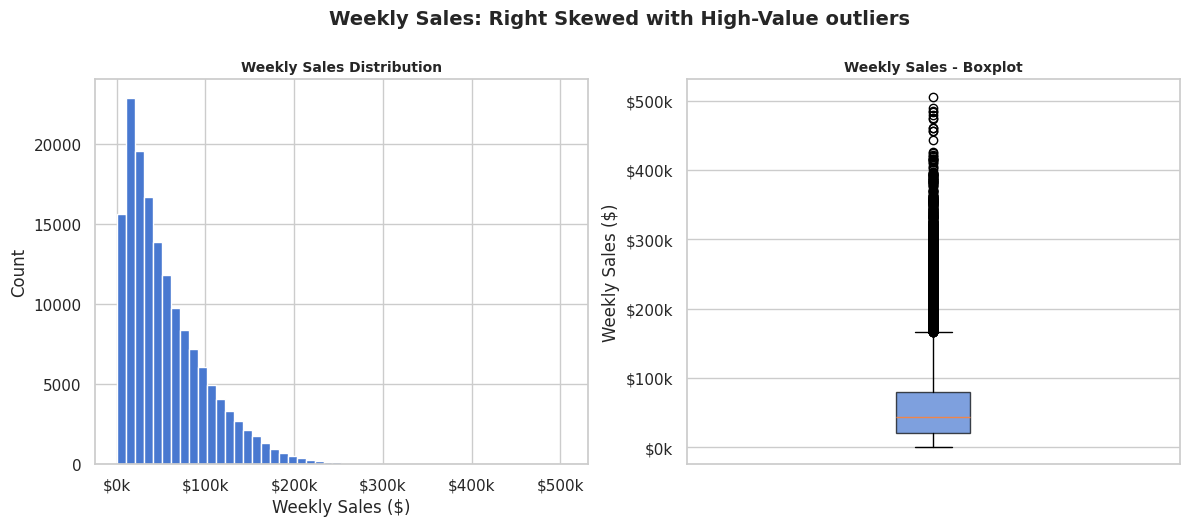

Mean: 56,503
Median: 43,395
Max: 505,959


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Weekly_Sales'], bins=50, color = PALETTE[0], edgecolor='white')
axes[0].set_title('Weekly Sales Distribution', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Box plot to show outliers
axes[1].boxplot(df['Weekly_Sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.7))
axes[1].set_title('Weekly Sales - Boxplot', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xticks([])

plt.suptitle('Weekly Sales: Right Skewed with High-Value outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout
plt.savefig('EDA 01 Sales Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean: {df['Weekly_Sales'].mean():,.0f}')
print(f'Median: {df['Weekly_Sales'].median():,.0f}')
print(f'Max: {df['Weekly_Sales'].max():,.0f}')

**Insight:** Sales are right-skewed the median ($43k) is well below the mean ($56k), meaning a small number of high-performing department-weeks pull the average up. The maximum of $506k likely comes from a large store during a holiday week.

---
## Sales By Store Type

The dataset has three store types (A, B, C). Type A stores are the largest, C the smallest. Does size translate directly to sales?

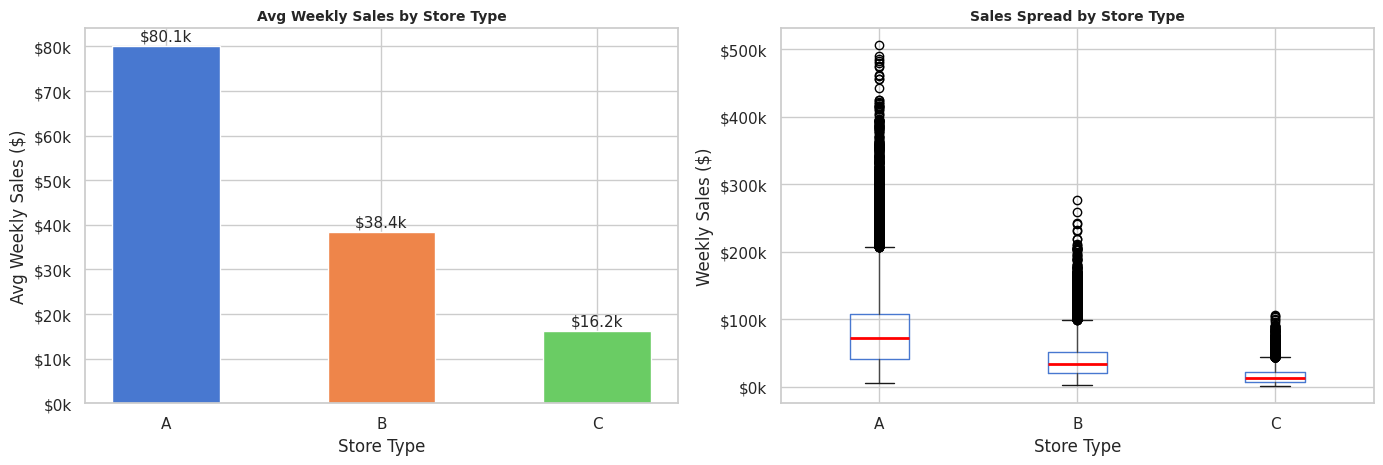

In [16]:
# To group by store type and find the mean of weekly sales
type_sales = df.groupby('Store_Type')['Weekly_Sales'].mean().round(2).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart with avg salesby store type
bars = axes[0].bar(type_sales['Store_Type'], type_sales['Weekly_Sales'],
                   color=PALETTE[:3], edgecolor='white', width=0.5)
axes[0].set_title('Avg Weekly Sales by Store Type', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${bar.get_height()/1000:.1f}k', ha='center', va='bottom', fontsize=11)
    
# Boxplot by store
df.boxplot(column='Weekly_Sales', by='Store_Type', ax=axes[1],
           boxprops=dict(color=PALETTE[0]),
           medianprops=dict(color='red',linewidth=2),
           patch_artist=False)
axes[1].set_title('Sales Spread By Store Type', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.sca(axes[1])
plt.title('Sales Spread by Store Type', fontsize=10, fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.savefig('EDA 02 Sales By Store Type.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Type A stores average **$80k/week**, more than double Type B ($38k) and nearly 5x Type C ($16k). Store type will be a very strong predictor in the model.

---
## Sales by Region

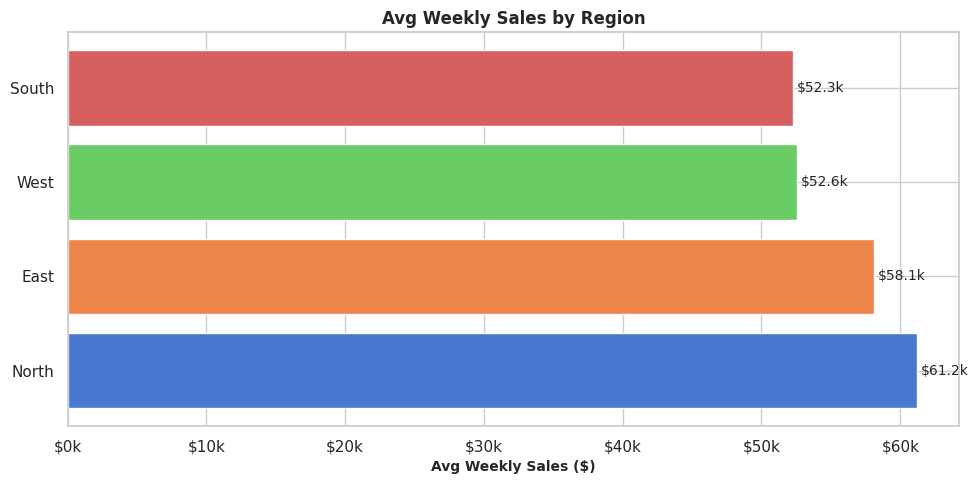

In [17]:
region_sales = df.groupby('Region')['Weekly_Sales'].mean().round(2).sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(region_sales['Region'], region_sales['Weekly_Sales'],
               color=PALETTE[:4], edgecolor='white')
ax.set_title('Avg Weekly Sales by Region', fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Weekly Sales ($)', fontsize=10, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar in bars:
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width()/1000:.1f}k', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('EDA 03 Sales by Region.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** North leads with $61k average weekly sales, followed closely by East. South and West are similar at $52k. Regional variation is meaningful but less extreme than store type differences.

---
## Holiday vs Non-Holiday Sales

The dataset flags holiday weeks. Do holidays actually drive more sales?

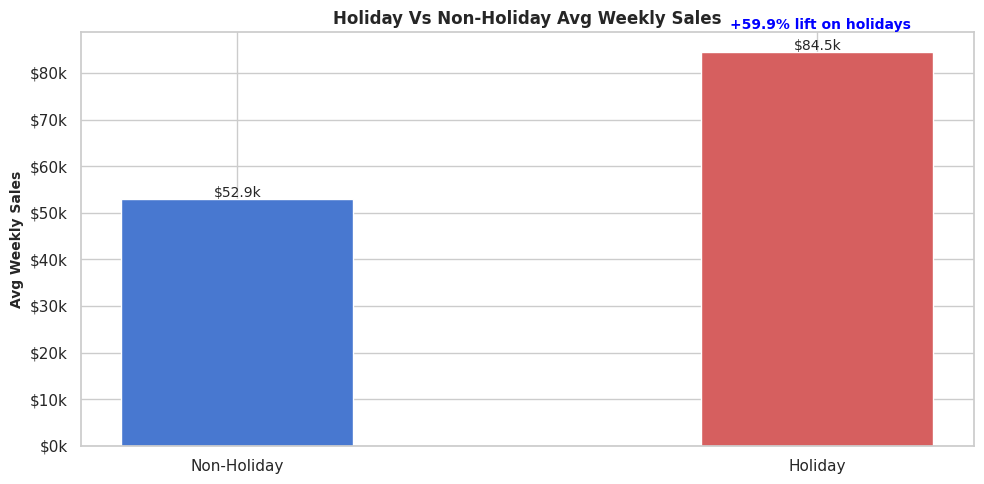

Holiday lift: +59.9% over non-holiday weeks


In [18]:
holiday_sales = df.groupby('Is_Holiday')['Weekly_Sales'].mean().round(2).reset_index()
holiday_sales['Label'] = holiday_sales['Is_Holiday'].map({0: 'Non-Holiday', 1: 'Holiday'})
lift = ((holiday_sales.loc[1, 'Weekly_Sales'] - holiday_sales.loc[0, 'Weekly_Sales'])
        / holiday_sales.loc[0, 'Weekly_Sales'] * 100)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(holiday_sales['Label'], holiday_sales['Weekly_Sales'],
              color=[PALETTE[0], PALETTE[3]], edgecolor='white', width=0.4)
ax.set_title('Holiday Vs Non-Holiday Avg Weekly Sales', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height()/1000:.1f}k', ha='center', fontsize=10)
ax.annotate(f'+{lift:.1f}% lift on holidays', xy=(1, holiday_sales.loc[1, 'Weekly_Sales']),
            xytext=(0.85, holiday_sales.loc[1, 'Weekly_Sales'] + 5000),
            fontsize=10, color='blue', fontweight='bold')
plt.tight_layout()
plt.savefig('EDA 04 Holiday Sales.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Holiday lift: +{lift:.1f}% over non-holiday weeks")

**Insight:** Holiday weeks generate **60% more sales** on average than non-holiday weeks. This is one of the strongest signals in the dataset and will be a key feature in the prediction model.

---
## Top 10 Departments by Average Weekly Sales

Out of 20 Departments, some are clearly high-volume than others

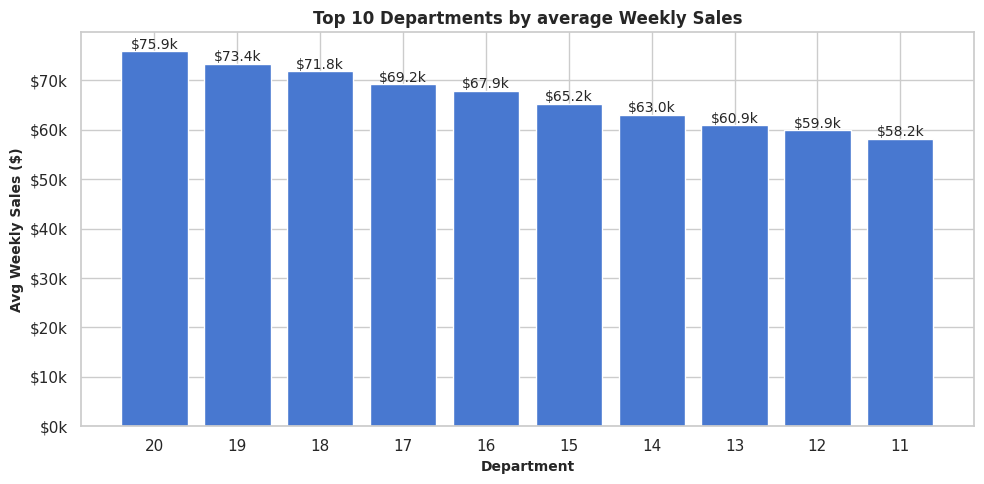

In [19]:
dept_sales = (df.groupby('Department')['Weekly_Sales'].mean().round(2)
              .sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dept_sales['Department'].astype(str), dept_sales['Weekly_Sales'],
              color=PALETTE[0], edgecolor='white')
ax.set_title('Top 10 Departments by average Weekly Sales', fontsize=12, fontweight='bold')
ax.set_xlabel('Department', fontsize=10, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($)', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height()/1000:.1f}k', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('EDA 05 Top Departments.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Store Size vs Weekly Sales

Figuring out if larger stores consistently outsell smaller ones

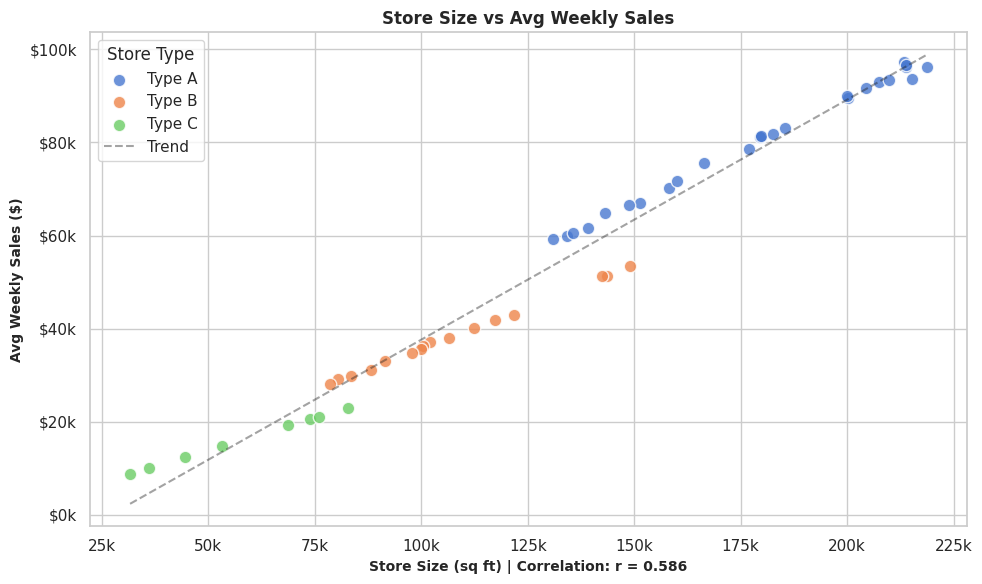

In [20]:
# Aggregate to store level: This avoids overplotting
store_agg = df.groupby(['Store_Id', 'Store_Size', 'Store_Type']).agg(
    Avg_Sales=('Weekly_Sales', 'mean')
).round(2).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
for stype, color in zip(['A', 'B', 'C'], PALETTE[:3]):
    sub = store_agg[store_agg['Store_Type'] == stype]
    ax.scatter(sub['Store_Size'], sub['Avg_Sales'], label=f'Type {stype}',
               color=color, s=80, alpha=0.8, edgecolors='white')
    
# Trend Line
from numpy.polynomial.polynomial import polyfit
x, y = store_agg['Store_Size'], store_agg['Avg_Sales']
b = polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, b[0] + b[1]*x_line, 'k--', alpha=0.4, label='Trend')

ax.set_title('Store Size vs Avg Weekly Sales', fontsize=12, fontweight='bold')
ax.set_xlabel('Store Size (sq ft)', fontsize=10, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($)', fontsize=10, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
corr = df[['Store_Size', 'Weekly_Sales']].corr().iloc[0, 1]
ax.set_xlabel(f'Store Size (sq ft) | Correlation: r = {corr:.3f}')
ax.legend(title='Store Type')
plt.tight_layout()
plt.savefig('EDA 06 Size vs Sales.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** There is a moderate positive correlation (r = 0.586) between store size and average weekly sales. Larger stores sell more, but the relationship is not perfectly linear, other factors like region and department mix also play a role.

---
## Correlation Heatmap (With Numeric Features)

Will show at a glance which numeric features are related to each other and to Weekly Sales

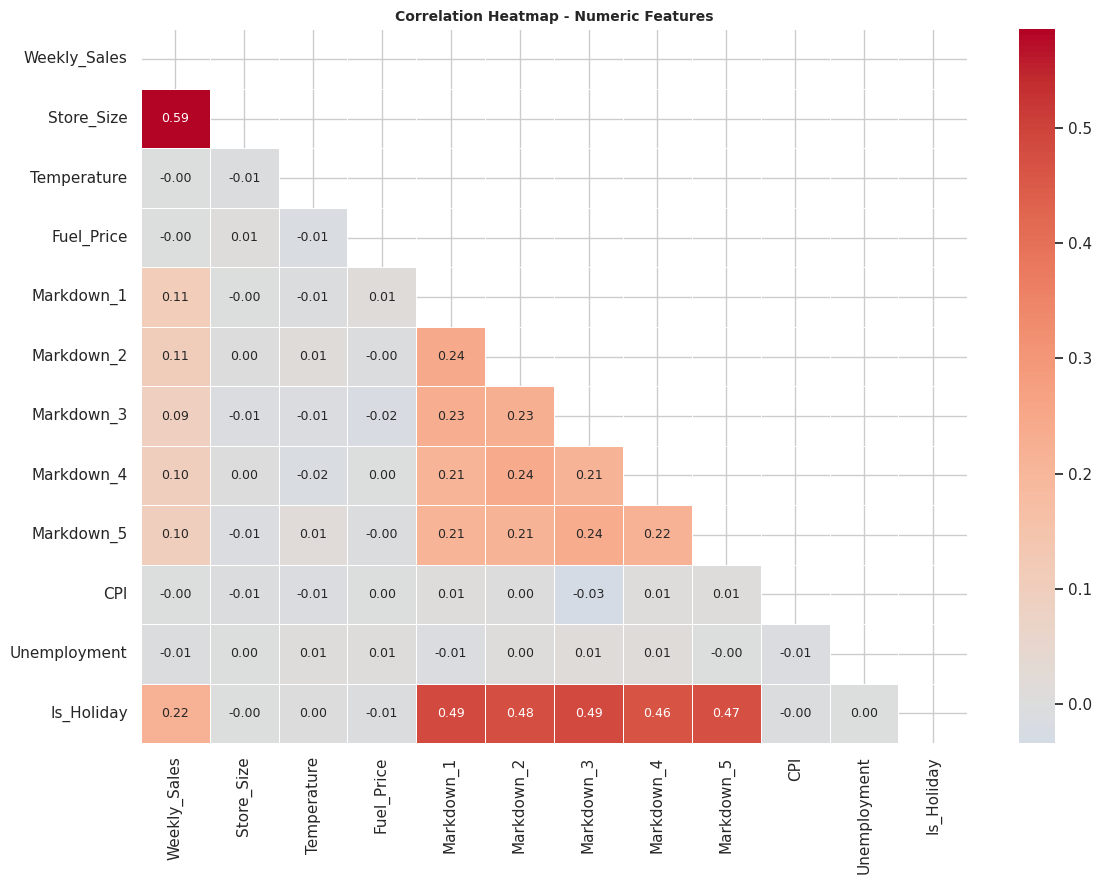

In [21]:
numeric_cols = ['Weekly_Sales', 'Store_Size', 'Temperature', 'Fuel_Price',
                'Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4', 'Markdown_5',
                'CPI', 'Unemployment', 'Is_Holiday']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap - Numeric Features', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA 07 Correlation Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- The first row/column shows which features have the strongest linera relationship with sales
- Markdown columns may be sparse (mostly outside promotion periods), so their correlation may appear weak

---
## EDA Summary (Key Findings)

| Finding | Detail |
|---|---|
| Sales are right-skewed | Median $43k, Mean $56k, a few very high-performing weeks pull the average up |
| Store type is the biggest driver | Type A averages $80k vs $16k for Type C, a 5x difference |
| Holiday weeks spike sales | 60% higher average sales on holiday weeks |
| North region leads | $61k avg vs $52k in South/West |
| Store size matters | r = 0.586 correlation with sales |
| Top departments dominate | Dept 20 averages $76k/week which is roughly 5x the dataset average |
